In [8]:
import os, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from copy import deepcopy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("✅ Device:", device)

EV_ROOT     = "../data/ev_real_world"
MODELS_DIR  = "../models"
RESULTS_DIR = "../results/metrics"
FIGS_DIR    = "../results/figures"
os.makedirs(FIGS_DIR, exist_ok=True)

# Lab scaler used only as reference — we'll fit a NEW one on EV data
import pickle as pkl
with open(f"{RESULTS_DIR}/scaler_X.pkl","rb") as f: scaler_X_lab = pkl.load(f)

FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end','EFC_norm']
WINDOW = 20   # snippets per sequence (same as lab cycles)
print(f"✅ Features: {FEATURE_COLS}")


✅ Device: mps
✅ Features: ['cap_Ah', 'v_mean', 'v_min', 'v_slope', 'i_mean', 't_mean', 't_max', 'energy_Wh', 'duration_min', 'soc_start', 'soc_end', 'EFC_norm']


In [9]:
def extract_features(arr, meta, max_mileage):
    """128×8 array + metadata → 12-dim feature vector matching lab."""
    V    = arr[:, 0]   # pack voltage
    I    = arr[:, 1]   # current (negative = charging)
    T    = arr[:, 2]   # pack temp
    t    = arr[:, 7]   # time (seconds)

    dt_h = 10.0 / 3600.0   # 10s steps in hours

    cap_Ah      = np.sum(np.abs(I)) * dt_h
    v_mean      = V.mean()
    v_min       = V.min()
    v_slope     = np.polyfit(np.arange(len(V)), V, 1)[0]
    i_mean      = I.mean()
    t_mean      = T.mean()
    t_max       = T.max()
    energy_Wh   = np.sum(np.abs(V * I)) * dt_h
    duration_min= (t[-1] - t[0]) / 60.0
    soc_start   = float(np.clip((V[0]  - 3.5) / (4.2 - 3.5), 0, 1))
    soc_end     = float(np.clip((V[-1] - 3.5) / (4.2 - 3.5), 0, 1))
    mileage     = meta.get("mileage", 0) or 0
    EFC_norm    = float(np.clip(mileage / max_mileage, 0, 1))

    return [cap_Ah, v_mean, v_min, v_slope, i_mean,
            t_mean, t_max, energy_Wh, duration_min,
            soc_start, soc_end, EFC_norm]

PARQUET_PATH = f"{RESULTS_DIR}/ev_snippets_features.parquet"

if os.path.exists(PARQUET_PATH):
    ev_df = pd.read_parquet(PARQUET_PATH)
    print(f"✅ Loaded cached EV features: {ev_df.shape}")
else:
    # First pass: get max mileage across all datasets for normalisation
    print("Pass 1/2: Computing max mileage...")
    max_mileage = 0.0
    for ds in ["battery_dataset1","battery_dataset2","battery_dataset3"]:
        lbl = pd.read_csv(f"{EV_ROOT}/{ds}/label/label.csv")
        data_dir = f"{EV_ROOT}/{ds}/data"
        sample_files = [f for f in os.listdir(data_dir)
                        if f.endswith(".pkl") and len(f.replace(".pkl",""))>4][:500]
        for pf in sample_files:
            try:
                obj  = torch.load(f"{data_dir}/{pf}", weights_only=False, map_location="cpu")
                meta = obj[1]
                m    = meta.get("mileage",0) or 0
                if m > max_mileage: max_mileage = m
            except: pass
    print(f"   Max mileage: {max_mileage:,.0f} km")

    # Second pass: extract all features
    print("Pass 2/2: Extracting features (this takes ~5-8 min)...")
    rows = []
    for ds in ["battery_dataset1","battery_dataset2","battery_dataset3"]:
        label_df = pd.read_csv(f"{EV_ROOT}/{ds}/label/label.csv")
        car_label = dict(zip(label_df["car"], label_df["label"]))
        data_dir  = f"{EV_ROOT}/{ds}/data"
        all_files = [f for f in os.listdir(data_dir)
                     if f.endswith(".pkl") and len(f.replace(".pkl",""))>4]
        print(f"  {ds}: {len(all_files):,} snippets...")
        for i, pf in enumerate(all_files):
            if i % 50000 == 0: print(f"    {i:,}/{len(all_files):,}")
            try:
                obj  = torch.load(f"{data_dir}/{pf}", weights_only=False, map_location="cpu")
                arr, meta = np.array(obj[0]), obj[1]
                if arr.shape != (128, 8): continue
                car   = meta.get("car", -1)
                seg   = int(meta.get("charge_segment", 0))
                label = int(car_label.get(car, -1))
                if label == -1: continue
                feats = extract_features(arr, meta, max_mileage)
                rows.append([car, seg, label, ds] + feats)
            except: pass

    ev_df = pd.DataFrame(rows,
                         columns=["car","segment","label","dataset"] + FEATURE_COLS)
    ev_df.sort_values(["car","segment"], inplace=True)
    ev_df.reset_index(drop=True, inplace=True)
    ev_df.to_parquet(PARQUET_PATH, index=False)
    print(f"✅ Saved EV features: {ev_df.shape}")

print(f"\nCars: {ev_df['car'].nunique()} | Snippets: {len(ev_df):,}")
print(f"Label dist:\n{ev_df.drop_duplicates('car')['label'].value_counts()}")


Pass 1/2: Computing max mileage...
   Max mileage: 262,359 km
Pass 2/2: Extracting features (this takes ~5-8 min)...
  battery_dataset1: 451,787 snippets...
    0/451,787
    50,000/451,787
    100,000/451,787
    150,000/451,787
    200,000/451,787
    250,000/451,787
    300,000/451,787
    350,000/451,787
    400,000/451,787
    450,000/451,787
  battery_dataset2: 457,672 snippets...
    0/457,672
    50,000/457,672
    100,000/457,672
    150,000/457,672
    200,000/457,672
    250,000/457,672
    300,000/457,672
    350,000/457,672
    400,000/457,672
    450,000/457,672
  battery_dataset3: 166,327 snippets...
    0/166,327
    50,000/166,327
    100,000/166,327
    150,000/166,327
✅ Saved EV features: (1075772, 16)

Cars: 459 | Snippets: 1,075,772
Label dist:
label
0    411
1     48
Name: count, dtype: int64


In [10]:
np.random.seed(42)

car_meta = ev_df.drop_duplicates("car")[["car","label","dataset"]].reset_index(drop=True)

# Stratified split by label within each dataset to preserve class balance
from sklearn.model_selection import train_test_split

train_cars, temp_cars = train_test_split(
    car_meta, test_size=0.3, stratify=car_meta["label"], random_state=42)
val_cars, test_cars   = train_test_split(
    temp_cars, test_size=0.5, stratify=temp_cars["label"], random_state=42)

train_ids = set(train_cars["car"])
val_ids   = set(val_cars["car"])
test_ids  = set(test_cars["car"])

ev_df["split"] = ev_df["car"].map(
    lambda c: "train" if c in train_ids
              else ("val" if c in val_ids else "test"))

for s in ["train","val","test"]:
    sub = ev_df[ev_df["split"]==s]
    cars_s = sub.drop_duplicates("car")
    print(f"{s:5s}: {cars_s['car'].nunique():3d} cars | "
          f"{len(sub):8,} snippets | "
          f"degraded: {(cars_s['label']==1).sum()} cars "
          f"({(cars_s['label']==1).mean()*100:.1f}%)")


train: 321 cars |  731,353 snippets | degraded: 34 cars (10.6%)
val  :  69 cars |  165,045 snippets | degraded: 7 cars (10.1%)
test :  69 cars |  179,374 snippets | degraded: 7 cars (10.1%)


In [11]:
train_df = ev_df[ev_df["split"]=="train"]

scaler_X_ev = StandardScaler()
scaler_X_ev.fit(train_df[FEATURE_COLS])

import pickle as pkl
with open(f"{RESULTS_DIR}/scaler_X_ev.pkl","wb") as f: pkl.dump(scaler_X_ev, f)
print("✅ EV scaler fitted on train set")
print(f"   Feature means:  {scaler_X_ev.mean_.round(3)}")
print(f"   Feature scales: {scaler_X_ev.scale_.round(3)}")


✅ EV scaler fitted on train set
   Feature means:  [  7.961   3.893   3.865   0.    -22.389  65.177  67.928  30.858  21.167
   0.52    0.589   0.287]
   Feature scales: [ 9.384  0.181  0.184  0.    26.392 22.506 22.49  36.442  1.     0.258
  0.256  0.197]


In [12]:
class EVCarDataset(Dataset):
    """
    One sample = 20-snippet window for one car.
    Label = car-level binary degradation (0/1).
    """
    def __init__(self, df, scaler_X, window=WINDOW, stride=5):
        self.samples = []
        for car_id, grp in df.groupby("car"):
            grp    = grp.sort_values("segment").reset_index(drop=True)
            label  = int(grp["label"].iloc[0])
            X      = scaler_X.transform(grp[FEATURE_COLS].values).astype(np.float32)
            efc    = grp["EFC_norm"].values.astype(np.float32)

            for i in range(window, len(grp), stride):
                self.samples.append((
                    torch.tensor(X[i-window:i]),
                    torch.tensor(label,  dtype=torch.long),
                    torch.tensor(efc[i], dtype=torch.float32)
                ))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


train_ds_ev = EVCarDataset(ev_df[ev_df["split"]=="train"], scaler_X_ev)
val_ds_ev   = EVCarDataset(ev_df[ev_df["split"]=="val"],   scaler_X_ev, stride=10)
test_ds_ev  = EVCarDataset(ev_df[ev_df["split"]=="test"],  scaler_X_ev, stride=10)

# Class weights for imbalanced labels
n_neg = sum(1 for _, lbl, _ in train_ds_ev.samples if lbl.item()==0)
n_pos = sum(1 for _, lbl, _ in train_ds_ev.samples if lbl.item()==1)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Class balance  neg={n_neg:,}  pos={n_pos:,}  pos_weight={pos_weight.item():.2f}")

train_loader_ev = DataLoader(train_ds_ev, batch_size=512, shuffle=True,  num_workers=0)
val_loader_ev   = DataLoader(val_ds_ev,   batch_size=512, shuffle=False, num_workers=0)
test_loader_ev  = DataLoader(test_ds_ev,  batch_size=512, shuffle=False, num_workers=0)

xb, yb, efc = next(iter(train_loader_ev))
print(f"✅ EV DataLoaders ready | X:{xb.shape} y:{yb.shape}")


Class balance  neg=130,319  pos=14,797  pos_weight=8.81
✅ EV DataLoaders ready | X:torch.Size([512, 20, 12]) y:torch.Size([512])


In [14]:
# ── PILSTM definition (copied from Notebook 03) ────────────
class PILSTM(nn.Module):
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4, fc_dims=[32,16]):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.h0_embed = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh()
        )
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )
        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def forward(self, x, efc_norm=None):
        if efc_norm is not None:
            h0 = self.h0_embed(efc_norm.unsqueeze(-1))
            h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
            c0 = torch.zeros_like(h0)
            out, _ = self.lstm(x, (h0, c0))
        else:
            out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


# ── Load pretrained lab weights ─────────────────────────────
lab_model = PILSTM(
    input_size=12, hidden_size=64,
    num_layers=2, dropout=0.4, fc_dims=[32,16]
).to(device)
lab_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/best_pilstm_v2.pt", map_location=device))
print(f"✅ Lab PI-LSTM loaded  "
      f"(params: {sum(p.numel() for p in lab_model.parameters()):,})")


# ── EV Classifier: frozen encoder + new head ────────────────
class EVClassifier(nn.Module):
    def __init__(self, base: PILSTM, freeze_encoder=True):
        super().__init__()
        self.lstm     = deepcopy(base.lstm)
        self.h0_embed = deepcopy(base.h0_embed)

        if freeze_encoder:
            for p in self.lstm.parameters():     p.requires_grad = False
            for p in self.h0_embed.parameters(): p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, efc_norm):
        h0  = self.h0_embed(efc_norm.unsqueeze(-1))
        h0  = h0.unsqueeze(0).repeat(self.lstm.num_layers, 1, 1)
        c0  = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.classifier(out[:, -1, :]).squeeze(-1)


ev_model = EVClassifier(lab_model, freeze_encoder=True).to(device)
n_train  = sum(p.numel() for p in ev_model.parameters() if p.requires_grad)
n_total  = sum(p.numel() for p in ev_model.parameters())
print(f"✅ EV Classifier | trainable: {n_train:,} / {n_total:,} params")
# Expected: trainable ~1,000 (head only) / ~57,000 total

✅ Lab PI-LSTM loaded  (params: 56,001)
✅ EV Classifier | trainable: 2,113 / 55,489 params


In [15]:
LR_P1     = 1e-3
EPOCHS_P1 = 20
PATIENCE  = 5

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, ev_model.parameters()),
    lr=LR_P1, weight_decay=1e-5)

best_val, patience_c = float("inf"), 0
hist = {"train":[], "val":[], "auc":[]}

print(f"🚀 Phase 1 — frozen encoder, {EPOCHS_P1} epochs\n")

for epoch in range(1, EPOCHS_P1+1):
    ev_model.train()
    train_loss = 0.0
    for xb, yb, efc in train_loader_ev:
        xb, yb, efc = xb.to(device), yb.float().to(device), efc.to(device)
        optimizer.zero_grad()
        logits = ev_model(xb, efc)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ev)

    ev_model.eval()
    val_loss, all_logits, all_labels = 0.0, [], []
    with torch.no_grad():
        for xb, yb, efc in val_loader_ev:
            xb, yb, efc = xb.to(device), yb.float().to(device), efc.to(device)
            logits     = ev_model(xb, efc)
            val_loss  += criterion(logits, yb).item()
            all_logits.extend(logits.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    val_loss /= len(val_loader_ev)
    auc = roc_auc_score(all_labels, all_logits)

    hist["train"].append(train_loss)
    hist["val"].append(val_loss)
    hist["auc"].append(auc)

    if val_loss < best_val - 1e-4:
        best_val, patience_c = val_loss, 0
        torch.save(ev_model.state_dict(), f"{MODELS_DIR}/ev_cls_frozen.pt")
    else:
        patience_c += 1

    print(f"Epoch {epoch:2d}/{EPOCHS_P1} | "
          f"train={train_loss:.4f} | val={val_loss:.4f} | "
          f"AUC={auc:.4f} | patience={patience_c}/{PATIENCE}")

    if patience_c >= PATIENCE:
        print("⏹ Early stopping")
        break

print(f"\n✅ Phase 1 complete | best val={best_val:.4f}")


🚀 Phase 1 — frozen encoder, 20 epochs

Epoch  1/20 | train=1.2182 | val=0.9919 | AUC=0.6769 | patience=0/5
Epoch  2/20 | train=1.1797 | val=0.9693 | AUC=0.6904 | patience=0/5
Epoch  3/20 | train=1.1645 | val=0.9494 | AUC=0.7097 | patience=0/5
Epoch  4/20 | train=1.1560 | val=0.9628 | AUC=0.6876 | patience=1/5
Epoch  5/20 | train=1.1526 | val=0.9545 | AUC=0.6995 | patience=2/5
Epoch  6/20 | train=1.1489 | val=0.9505 | AUC=0.7016 | patience=3/5
Epoch  7/20 | train=1.1446 | val=0.9424 | AUC=0.7119 | patience=0/5
Epoch  8/20 | train=1.1422 | val=0.9338 | AUC=0.7186 | patience=0/5
Epoch  9/20 | train=1.1386 | val=0.9395 | AUC=0.7121 | patience=1/5
Epoch 10/20 | train=1.1382 | val=0.9542 | AUC=0.6937 | patience=2/5
Epoch 11/20 | train=1.1309 | val=0.9297 | AUC=0.7214 | patience=0/5
Epoch 12/20 | train=1.1271 | val=0.9339 | AUC=0.7145 | patience=1/5
Epoch 13/20 | train=1.1267 | val=0.9267 | AUC=0.7294 | patience=0/5
Epoch 14/20 | train=1.1209 | val=0.9328 | AUC=0.7245 | patience=1/5
Epoch 15/

In [16]:
# Unfreeze everything
for p in ev_model.parameters(): p.requires_grad = True

optimizer = torch.optim.Adam(ev_model.parameters(), lr=3e-4, weight_decay=1e-5)
best_val2, patience_c = float("inf"), 0

print("🚀 Phase 2 — full fine-tune, 20 epochs\n")

for epoch in range(1, 21):
    ev_model.train()
    train_loss = 0.0
    for xb, yb, efc in train_loader_ev:
        xb, yb, efc = xb.to(device), yb.float().to(device), efc.to(device)
        optimizer.zero_grad()
        logits = ev_model(xb, efc)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ev_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ev)

    ev_model.eval()
    val_loss, all_logits, all_labels = 0.0, [], []
    with torch.no_grad():
        for xb, yb, efc in val_loader_ev:
            xb, yb, efc = xb.to(device), yb.float().to(device), efc.to(device)
            logits    = ev_model(xb, efc)
            val_loss += criterion(logits, yb).item()
            all_logits.extend(logits.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    val_loss /= len(val_loader_ev)
    auc = roc_auc_score(all_labels, all_logits)

    print(f"Epoch {epoch:2d}/20 | train={train_loss:.4f} | "
          f"val={val_loss:.4f} | AUC={auc:.4f} | patience={patience_c}/5")

    if val_loss < best_val2 - 1e-4:
        best_val2, patience_c = val_loss, 0
        torch.save(ev_model.state_dict(), f"{MODELS_DIR}/ev_cls_full_ft.pt")
    else:
        patience_c += 1
    if patience_c >= 5:
        print("⏹ Early stopping")
        break

print(f"\n✅ Phase 2 complete | best val={best_val2:.4f}")


🚀 Phase 2 — full fine-tune, 20 epochs

Epoch  1/20 | train=0.9584 | val=0.9112 | AUC=0.7407 | patience=0/5
Epoch  2/20 | train=0.7752 | val=0.9037 | AUC=0.7496 | patience=0/5
Epoch  3/20 | train=0.7365 | val=0.8899 | AUC=0.7618 | patience=0/5
Epoch  4/20 | train=0.7067 | val=0.8992 | AUC=0.7488 | patience=0/5
Epoch  5/20 | train=0.6769 | val=0.9237 | AUC=0.7557 | patience=1/5
Epoch  6/20 | train=0.6603 | val=0.9355 | AUC=0.7577 | patience=2/5
Epoch  7/20 | train=0.6510 | val=0.8932 | AUC=0.7641 | patience=3/5
Epoch  8/20 | train=0.6301 | val=0.8839 | AUC=0.7747 | patience=4/5
Epoch  9/20 | train=0.6194 | val=0.8998 | AUC=0.7776 | patience=0/5
Epoch 10/20 | train=0.6046 | val=0.8773 | AUC=0.7820 | patience=1/5
Epoch 11/20 | train=0.5909 | val=0.8960 | AUC=0.7800 | patience=0/5
Epoch 12/20 | train=0.5770 | val=0.9865 | AUC=0.7650 | patience=1/5
Epoch 13/20 | train=0.5671 | val=0.9862 | AUC=0.7705 | patience=2/5
Epoch 14/20 | train=0.5557 | val=0.8942 | AUC=0.7931 | patience=3/5
Epoch 15/

TEST RESULTS — EV Transfer PI-LSTM Classifier
  ROC-AUC          : 0.8896
  Balanced Accuracy: 0.8226
              precision    recall  f1-score   support

      Normal       0.94      0.87      0.90     14093
    Degraded       0.61      0.78      0.68      3733

    accuracy                           0.85     17826
   macro avg       0.77      0.82      0.79     17826
weighted avg       0.87      0.85      0.85     17826



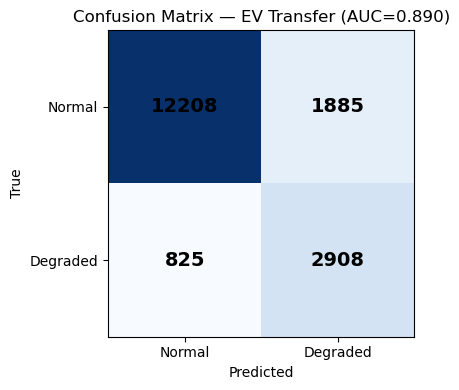

In [17]:
# Load the best model (full_ft usually wins)
best_path = f"{MODELS_DIR}/ev_cls_full_ft.pt"
ev_model.load_state_dict(torch.load(best_path, map_location=device))
ev_model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb, efc in test_loader_ev:
        xb, efc = xb.to(device), efc.to(device)
        logits  = ev_model(xb, efc)
        all_logits.extend(logits.cpu().numpy())
        all_labels.extend(yb.numpy())

all_logits = np.array(all_logits)
all_labels = np.array(all_labels)
all_probs  = torch.sigmoid(torch.tensor(all_logits)).numpy()
all_preds  = (all_probs > 0.5).astype(int)

auc      = roc_auc_score(all_labels, all_probs)
bal_acc  = balanced_accuracy_score(all_labels, all_preds)

print("=" * 52)
print("TEST RESULTS — EV Transfer PI-LSTM Classifier")
print("=" * 52)
print(f"  ROC-AUC          : {auc:.4f}")
print(f"  Balanced Accuracy: {bal_acc:.4f}")
print("=" * 52)
print(classification_report(all_labels, all_preds,
                             target_names=["Normal","Degraded"]))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Normal","Degraded"])
ax.set_yticklabels(["Normal","Degraded"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — EV Transfer (AUC={auc:.3f})")
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ev_confusion_matrix.png", dpi=150)
plt.show()


Default threshold : 0.500
Optimal threshold : 0.762

Fix 1 — threshold=0.762
  ROC-AUC          : 0.8896  (unchanged)
  Balanced Accuracy: 0.8287  (was 0.8226)
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95     14093
    Degraded       0.89      0.68      0.77      3733

    accuracy                           0.92     17826
   macro avg       0.91      0.83      0.86     17826
weighted avg       0.91      0.92      0.91     17826



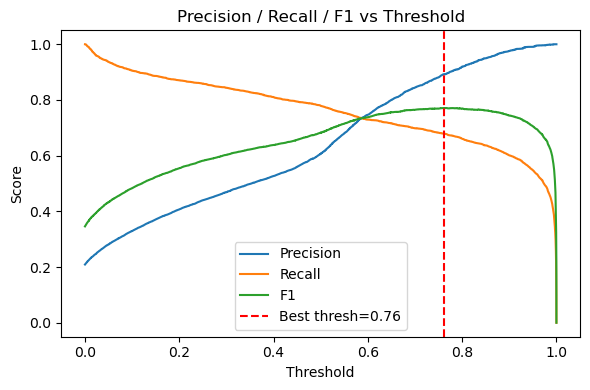

In [18]:
from sklearn.metrics import precision_recall_curve, f1_score

# all_logits and all_labels already exist from Cell 9
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Default threshold : 0.500")
print(f"Optimal threshold : {best_thresh:.3f}")
print()

all_preds_opt = (all_probs > best_thresh).astype(int)
auc_opt       = roc_auc_score(all_labels, all_probs)         # AUC unchanged
bal_opt       = balanced_accuracy_score(all_labels, all_preds_opt)

print("="*52)
print(f"Fix 1 — threshold={best_thresh:.3f}")
print("="*52)
print(f"  ROC-AUC          : {auc_opt:.4f}  (unchanged)")
print(f"  Balanced Accuracy: {bal_opt:.4f}  (was 0.8226)")
print("="*52)
print(classification_report(all_labels, all_preds_opt,
                             target_names=["Normal","Degraded"]))

# PR curve plot
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1],    label="Recall")
plt.plot(thresholds, f1_scores[:-1],  label="F1")
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f"Best thresh={best_thresh:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend(); plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ev_threshold_curve.png", dpi=150)
plt.show()


In [19]:
class EVCarDatasetWithID(EVCarDataset):
    """Same as EVCarDataset but __getitem__ also returns car_id."""
    def __init__(self, df, scaler_X, window=WINDOW, stride=10):
        self.samples = []
        for car_id, grp in df.groupby("car"):
            grp   = grp.sort_values("segment").reset_index(drop=True)
            label = int(grp["label"].iloc[0])
            X     = scaler_X.transform(grp[FEATURE_COLS].values).astype(np.float32)
            efc   = grp["EFC_norm"].values.astype(np.float32)
            for i in range(window, len(grp), stride):
                self.samples.append((
                    torch.tensor(X[i-window:i]),
                    torch.tensor(label,   dtype=torch.long),
                    torch.tensor(efc[i],  dtype=torch.float32),
                    car_id                                      # ← added
                ))

    def __getitem__(self, idx):
        x, y, efc, car_id = self.samples[idx]
        return x, y, efc, car_id


# Rebuild test loader only (train/val unchanged)
test_ds_ev_id  = EVCarDatasetWithID(ev_df[ev_df["split"]=="test"], scaler_X_ev)
test_loader_id = DataLoader(test_ds_ev_id, batch_size=512,
                             shuffle=False, num_workers=0,
                             collate_fn=lambda b: (
                                 torch.stack([s[0] for s in b]),
                                 torch.stack([s[1] for s in b]),
                                 torch.stack([s[2] for s in b]),
                                 [s[3] for s in b]             # car_ids as list
                             ))

xb, yb, efc, cids = next(iter(test_loader_id))
print(f"✅ Test loader with IDs | X:{xb.shape}  car_ids sample: {cids[:4]}")


✅ Test loader with IDs | X:torch.Size([512, 20, 12])  car_ids sample: [3, 3, 3, 3]


Car-level test set: 68 cars
Degraded: 6  Normal: 62

FIX 1 + FIX 2 — Car-level evaluation
  ROC-AUC                     : 0.9409
  Balanced Acc (thresh=0.50)  : 0.9086
  Balanced Acc (thresh=0.53)  : 0.8333  ← best

Classification report (thresh=0.53):
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98        62
    Degraded       1.00      0.67      0.80         6

    accuracy                           0.97        68
   macro avg       0.98      0.83      0.89        68
weighted avg       0.97      0.97      0.97        68



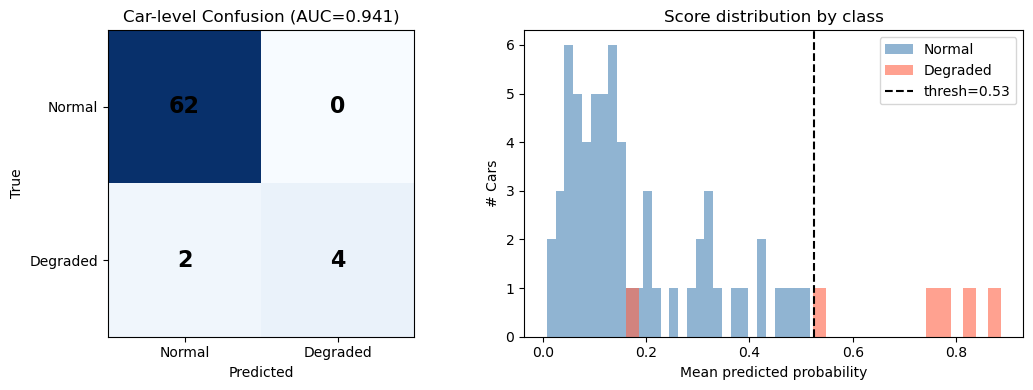

💾 Saved → results/metrics/ev_car_predictions.csv


In [20]:
ev_model.eval()
snippet_rows = []

with torch.no_grad():
    for xb, yb, efc, car_ids in test_loader_id:
        xb, efc = xb.to(device), efc.to(device)
        logits  = ev_model(xb, efc).cpu().numpy()
        probs   = torch.sigmoid(torch.tensor(logits)).numpy()
        for i, car_id in enumerate(car_ids):
            snippet_rows.append({
                "car_id"    : car_id,
                "true_label": int(yb[i].item()),
                "prob"      : float(probs[i])
            })

snip_df = pd.DataFrame(snippet_rows)

# Aggregate: mean prob per car → car-level prediction
car_df = snip_df.groupby("car_id").agg(
    true_label = ("true_label", "first"),
    mean_prob  = ("prob",       "mean"),
    max_prob   = ("prob",       "max"),
    n_snippets = ("prob",       "count")
).reset_index()

print(f"Car-level test set: {len(car_df)} cars")
print(f"Degraded: {(car_df['true_label']==1).sum()}  "
      f"Normal: {(car_df['true_label']==0).sum()}")

# ── Evaluate with both fixes ───────────────────────────────
# Fix 1 applied at car level too
car_precs, car_recs, car_thresh = precision_recall_curve(
    car_df["true_label"], car_df["mean_prob"])
car_f1s = 2 * car_precs * car_recs / (car_precs + car_recs + 1e-8)
best_car_thresh = car_thresh[np.argmax(car_f1s)]

car_preds_05  = (car_df["mean_prob"] > 0.50).astype(int)
car_preds_opt = (car_df["mean_prob"] > best_car_thresh).astype(int)

car_auc      = roc_auc_score(car_df["true_label"], car_df["mean_prob"])
car_bal_05   = balanced_accuracy_score(car_df["true_label"], car_preds_05)
car_bal_opt  = balanced_accuracy_score(car_df["true_label"], car_preds_opt)

print("\n" + "="*55)
print("FIX 1 + FIX 2 — Car-level evaluation")
print("="*55)
print(f"  ROC-AUC                     : {car_auc:.4f}")
print(f"  Balanced Acc (thresh=0.50)  : {car_bal_05:.4f}")
print(f"  Balanced Acc (thresh={best_car_thresh:.2f})  : {car_bal_opt:.4f}  ← best")
print("="*55)
print(f"\nClassification report (thresh={best_car_thresh:.2f}):")
print(classification_report(car_df["true_label"], car_preds_opt,
                             target_names=["Normal","Degraded"]))

# Confusion matrix — car level
cm_car = confusion_matrix(car_df["true_label"], car_preds_opt)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: car-level confusion matrix
ax = axes[0]
ax.imshow(cm_car, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Normal","Degraded"])
ax.set_yticklabels(["Normal","Degraded"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_car[i,j], ha="center", va="center",
                fontsize=16, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Car-level Confusion (AUC={car_auc:.3f})")

# Right: mean prob distribution per class
ax2 = axes[1]
ax2.hist(car_df[car_df["true_label"]==0]["mean_prob"],
         bins=30, alpha=0.6, label="Normal", color="steelblue")
ax2.hist(car_df[car_df["true_label"]==1]["mean_prob"],
         bins=30, alpha=0.6, label="Degraded", color="tomato")
ax2.axvline(best_car_thresh, color="black", linestyle="--",
            label=f"thresh={best_car_thresh:.2f}")
ax2.set_xlabel("Mean predicted probability"); ax2.set_ylabel("# Cars")
ax2.set_title("Score distribution by class")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ev_car_level_eval.png", dpi=150)
plt.show()

# Save car-level predictions
car_df.to_csv(f"{RESULTS_DIR}/ev_car_predictions.csv", index=False)
print(f"💾 Saved → results/metrics/ev_car_predictions.csv")
